# Lab 3
### Averaging Filters

http://scikit-image.org/docs/0.13.x/api/skimage.util.html#skimage.util.random_noise

http://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.median

http://scikit-image.org/docs/dev/api/skimage.filters.html#skimage.filters.gaussian

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


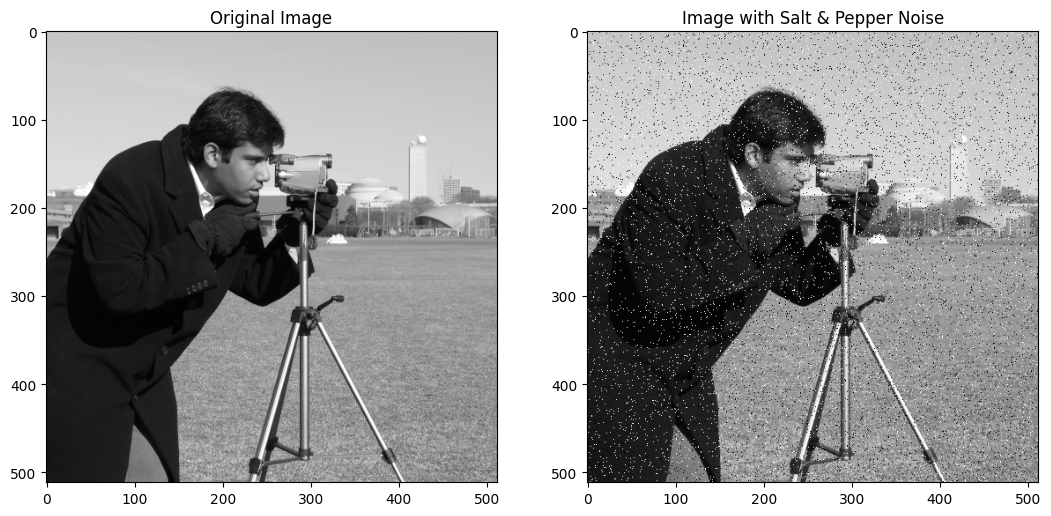

In [2]:
from commonfunctions import *
import numpy as np
import skimage.io as io
from skimage.util import random_noise
from skimage.filters import median, gaussian

%matplotlib inline
%load_ext autoreload
%autoreload 2

from skimage.data import camera
from skimage.color import rgb2gray
import numpy as np
from skimage.morphology import square

img = camera()

noisy_img = random_noise(img, mode='s&p', amount=0.05)

show_images([img, noisy_img], ["Original Image", "Image with Salt & Pepper Noise"])

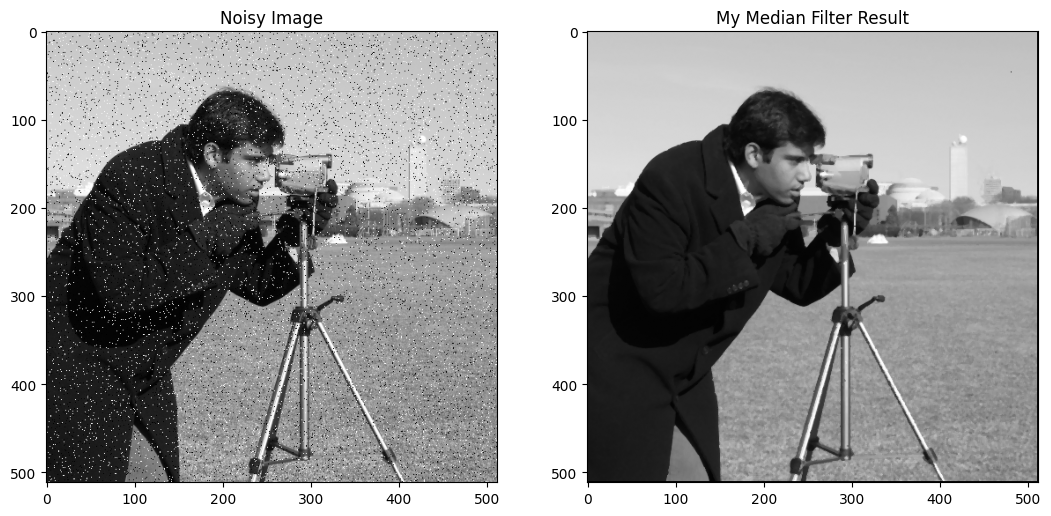

In [3]:
'''
(1) Your own median filter algorithm
'''

def my_median_filter(image, window_size=3):
    height, width = image.shape
    edge = window_size // 2
    output_image = np.zeros_like(image)
    
    for y in range(edge, height - edge):
        for x in range(edge, width - edge):
            window = image[y-edge : y+edge+1, x-edge : x+edge+1]
            
            median_value = np.median(window)
            
            output_image[y, x] = median_value
            
    return output_image

my_filtered_image = my_median_filter(noisy_img, window_size=3)

show_images([noisy_img, my_filtered_image], ["Noisy Image", "My Median Filter Result"])

/tmp/ipykernel_192194/292164559.py:5: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  skimage_filtered_image = median(noisy_img, footprint=square(3))


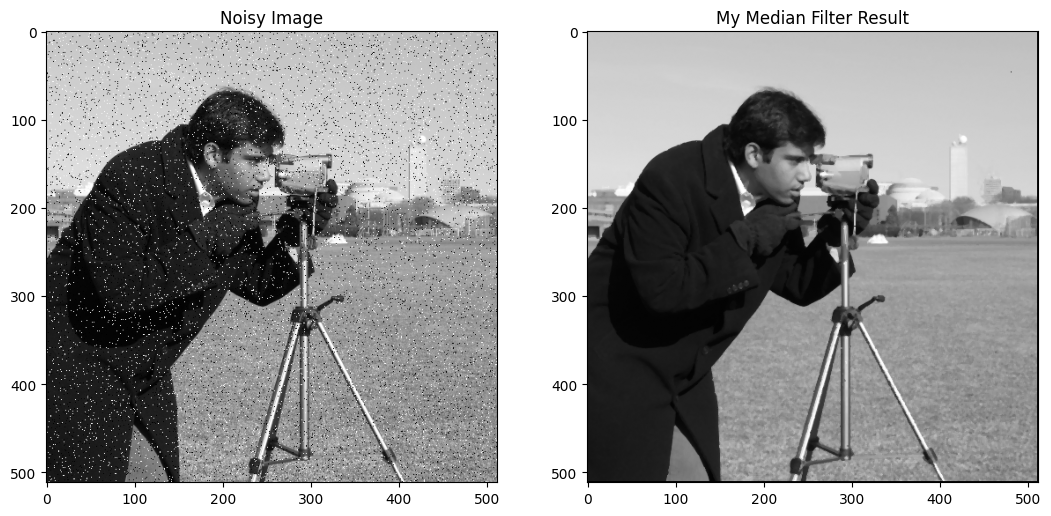

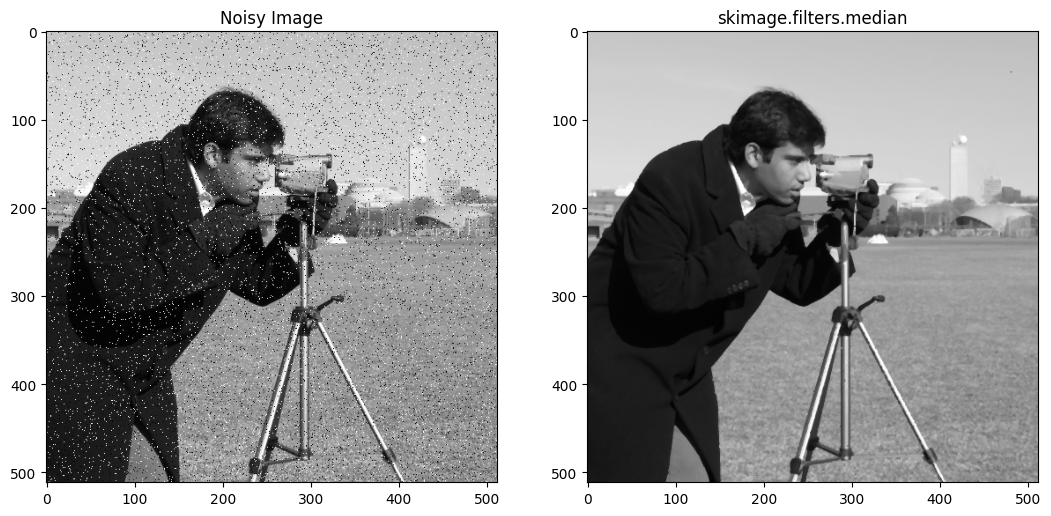

In [6]:
'''
(2) skimage median filter
'''

skimage_filtered_image = median(noisy_img, footprint=square(3))

show_images([noisy_img, my_filtered_image], ["Noisy Image", "My Median Filter Result"])

show_images([noisy_img, skimage_filtered_image], ["Noisy Image", "skimage.filters.median"])


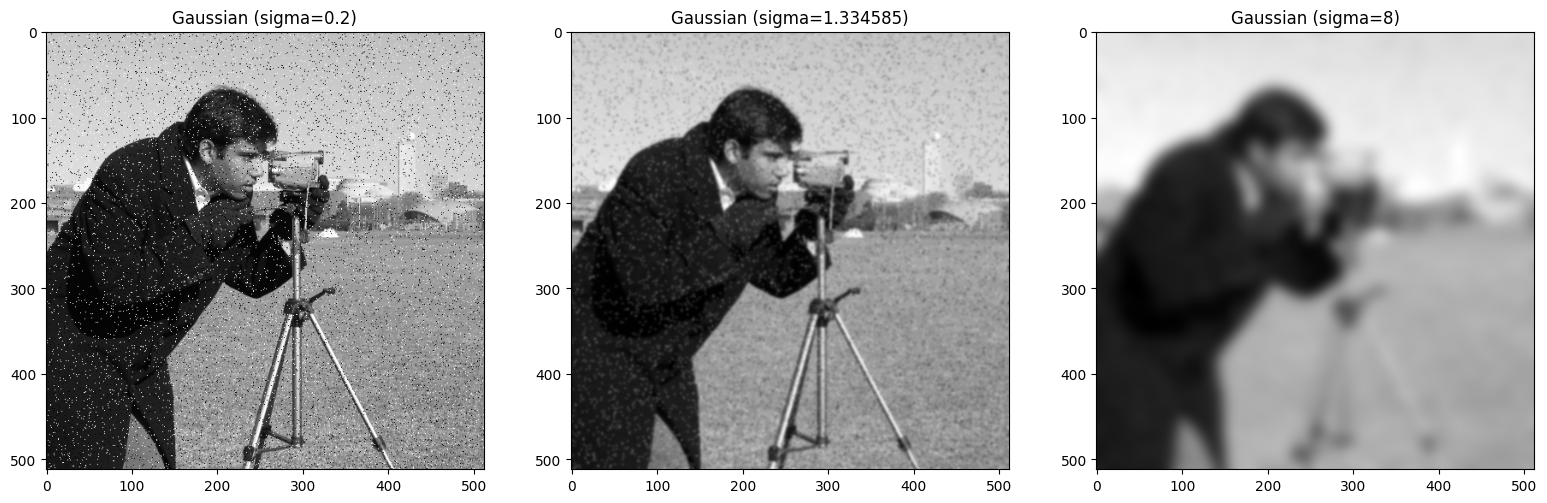

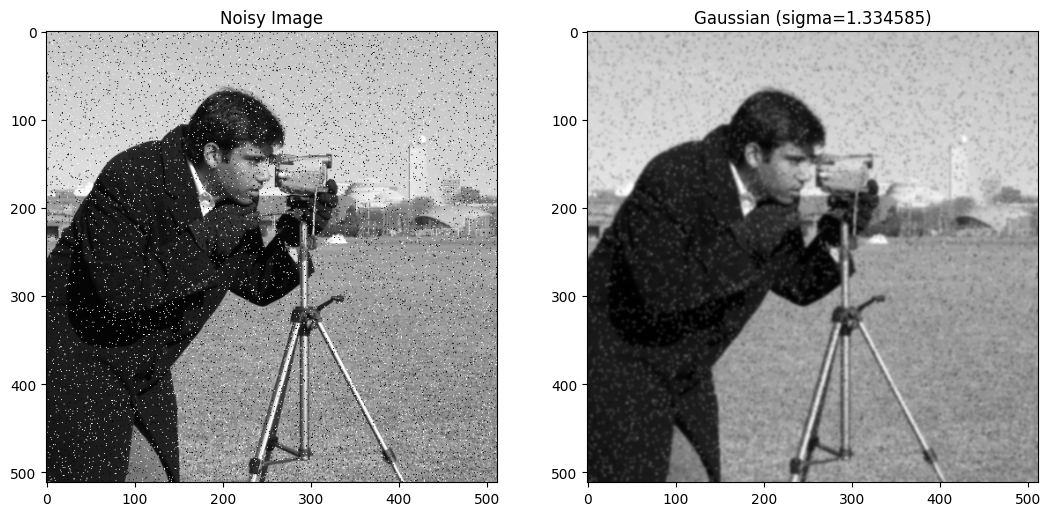

In [16]:
'''
(3) Gaussion Filters
'''
sigma_high = 8
sigma_medium = 1.334585
sigma_low = 0.2

gaussian_high_sigma = gaussian(noisy_img, sigma=sigma_high)
gaussian_medium_sigma = gaussian(noisy_img, sigma=sigma_medium)
gaussian_low_sigma = gaussian(noisy_img, sigma=sigma_low)

# Display all the results for comparison
show_images([gaussian_low_sigma, gaussian_medium_sigma, gaussian_high_sigma], 
            [f"Gaussian (sigma={sigma_low})", f"Gaussian (sigma={sigma_medium})", f"Gaussian (sigma={sigma_high})"])

show_images([noisy_img , gaussian_medium_sigma], ["Noisy Image", f"Gaussian (sigma={sigma_medium})"])